# Chicago Crimes - Continual Learning, Drift Detection & Model Registry 

Notebook ini mensimulasikan **continual learning**: data tiba secara kronologis per batch, kita deteksi **data drift**, lakukan **retraining bersyarat (checkpoint)**, putuskan **deployment** (promote/reject/rollback), dan catat semua di **model registry**.

## 0. Setup, Palette, & Konfigurasi

In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

# Palette 
BRAND_INDIGO='#3D2B9E'; BRAND_VIOLET='#7B3FE4'; BRAND_MAGENTA='#CE1C8E'; BRAND_PINK='#EC6DB4'; BRAND_LIGHT='#F7B4DA'
BRAND_COLORS=[BRAND_MAGENTA, BRAND_INDIGO, BRAND_VIOLET, BRAND_PINK, BRAND_LIGHT]
BRAND_CMAP=LinearSegmentedColormap.from_list('brand', ['#241663', BRAND_INDIGO, BRAND_VIOLET, BRAND_MAGENTA, BRAND_PINK, BRAND_LIGHT])
try:
    mpl.colormaps.register(BRAND_CMAP); mpl.colormaps.register(BRAND_CMAP.reversed())
except (ValueError, AttributeError):
    pass
plt.rcParams['axes.prop_cycle']=plt.cycler(color=BRAND_COLORS)
plt.rcParams['image.cmap']='brand'; plt.rcParams['figure.figsize']=(12,5); plt.rcParams['figure.dpi']=110
plt.rcParams['axes.grid']=True; plt.rcParams['grid.alpha']=0.25

RANDOM_STATE=42
TARGET='risk_score'
OUT_DIR='/kaggle/working' if os.path.isdir('/kaggle/working') else '.'

# Batas waktu
TRAIN_END='2021-12'   
print('OUT_DIR:', OUT_DIR)

OUT_DIR: /kaggle/working


## 1. Load Artefak NB06 & Data

Memuat: (1) `feature_list_ext.json` untuk daftar fitur diperluas (26 fitur termasuk lag-risk) dan tipe model terbaik, (2) `model_v2_lagrisk.joblib`, dan (3) `training_table.parquet` sebagai sumber data lengkap.

In [ ]:
import joblib, glob

NB06_DIRS=['/kaggle/input/notebooks/fransiskaadin/06-modelling', '/kaggle/working', '.']
NB05_DIRS=['/kaggle/input/datasets/fransiskaadin/training-table-chicago-crimes', '/kaggle/input/notebooks/fransiskaadin/05-pseudo-labeling-severity', '/kaggle/working', '.']

def find_file(filename, prefer_dirs=()):
    # 1) cek direktori prioritas persis
    for d in prefer_dirs:
        p=os.path.join(d, filename)
        if os.path.exists(p): return p
    # 2) fallback: cari rekursif (tahan variasi slug/versi dataset atau mount path berbeda)
    for root in ['/kaggle/input', '/kaggle/working', '.']:
        if os.path.isdir(root):
            hits=sorted(glob.glob(os.path.join(root, '**', filename), recursive=True))
            if hits: return hits[0]
    return None

# 1) Metadata fitur diperluas
meta_path=find_file('feature_list_ext.json', NB06_DIRS)
if meta_path:
    meta=json.load(open(meta_path))
    FEATURES_EXT=meta['features']; RISK_LAG_COLS=meta.get('risk_lag_cols',['risk_lag_1','risk_lag_3','risk_lag_12'])
    MODEL_KIND=meta.get('best_model','RandomForest')
    NB06_TEST_MAE=float(meta.get('test_metrics',{}).get('MAE', np.nan))
    print('Meta NB06 dimuat dari', meta_path, '| model:', MODEL_KIND, '| n fitur:', len(FEATURES_EXT))
else:
    RISK_LAG_COLS=['risk_lag_1','risk_lag_3','risk_lag_12']; MODEL_KIND='RandomForest'; NB06_TEST_MAE=np.nan
    FEATURES_EXT=['glat','glon','gi','gj','year_idx','pmonth','pquarter','pmonth_sin','pmonth_cos','lag_1','lag_3','lag_12','roll3_mean','roll6_mean','roll12_mean','cell_hist_mean','trend_3_12','n_violent_lag1','arrest_rate_lag1','domestic_rate_lag1','neighbor_lag1_mean','share_night_lag1','share_weekend_lag1']+RISK_LAG_COLS
    print('feature_list_ext.json tidak ditemukan -> pakai default')

# 2) Data 
tbl=find_file('training_table.parquet', NB05_DIRS)
if tbl is None:
    raise FileNotFoundError(
        "training_table.parquet tidak ditemukan. Buka panel Input notebook Kaggle -> Add Input -> "
        "tambahkan dataset NB05 (05-pseudo-labeling-severity). Sudah dicari rekursif di /kaggle/input tapi nihil.")
print('training_table dimuat dari', tbl)
df=pd.read_parquet(tbl)
df['period_dt']=pd.to_datetime(df['period_str']+'-01')
df=df.sort_values(['gi','gj','period_dt']).reset_index(drop=True)
df=df[df['is_partial_period']==0].copy()

# 3) Rebuild fitur lag-risk 
for L in (1,3,12):
    col=f'risk_lag_{L}'
    if col not in df.columns:
        df[col]=df.groupby(['gi','gj'])[TARGET].shift(L)
global_mean=float(df[df['period_str']<=TRAIN_END][TARGET].mean())
df[RISK_LAG_COLS]=df[RISK_LAG_COLS].fillna(global_mean)
print('Data:', df.shape, '| periode', df['period_str'].min(), '->', df['period_str'].max())
print('Fitur hilang (harus []):', [c for c in FEATURES_EXT if c not in df.columns])

Meta NB06 dimuat dari /kaggle/input/notebooks/fransiskaadin/06-modelling/feature_list_ext.json | model: RandomForest | n fitur: 26
training_table dimuat dari /kaggle/input/datasets/fransiskaadin/training-table-chicago-crimes/training_table.parquet
Data: (226038, 45) | periode 2001-01 -> 2026-03
Fitur hilang (harus []): []


In [3]:
def assemble_features(frame, features=FEATURES_EXT):
    # Rakit matriks fitur dengan urutan kolom TETAP -> train/serving parity (sama seperti NB06)
    return frame.reindex(columns=features).astype('float32').fillna(0.0)

def regression_metrics(y_true, y_pred):
    yt=np.asarray(y_true,'float64'); yp=np.asarray(y_pred,'float64')
    ss=float(np.sum((yt-yp)**2)); st=float(np.sum((yt-yt.mean())**2))
    return {'MAE':float(np.mean(np.abs(yt-yp))), 'RMSE':float(np.sqrt(np.mean((yt-yp)**2))), 'R2':float(1-ss/st) if st>0 else 0.0}

# Champion v1: muat dari NB06; fallback latih ulang bila pickle tak tersedia/inkompatibel
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def build_estimator(kind):
    if kind=='HistGBR':
        return HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08, random_state=RANDOM_STATE)
    if kind=='Ridge':
        return make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=RANDOM_STATE))
    return RandomForestRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE)

c0=df[df['period_str']<=TRAIN_END]
X0=assemble_features(c0); y0=c0[TARGET].astype('float32')
mpath=find_file('model_v2_lagrisk.joblib', NB06_DIRS)
champion=None
if mpath:
    try:
        champion=joblib.load(mpath); print('Champion v1 dimuat dari', mpath)
    except Exception as e:
        print('Gagal load pickle (', e, ') -> latih ulang')
if champion is None:
    champion=build_estimator(MODEL_KIND).fit(X0, y0); print('Champion v1 dilatih ulang pada <=', TRAIN_END)
print('Tipe champion:', type(champion).__name__)

Champion v1 dimuat dari /kaggle/input/notebooks/fransiskaadin/06-modelling/model_v2_lagrisk.joblib
Tipe champion: RandomForestRegressor


## 2. Desain Simulasi Continual Learning

**Timeline.** Champion v1 = model NB06 (dilatih pada data hingga 2021-12). Setelah itu data "tiba" per **batch tahunan**: 2022, 2023, 2024, 2025, 2026 (Q1). Tiap batch diperlakukan sebagai data baru yang belum pernah dilihat.

**Protokol untuk setiap batch t:**
1. **Monitoring** - champion memprediksi batch t (belum pernah dilihat) -> MAE/R2 sebagai sinyal performa.
2. **Drift detection** - hitung PSI (Population Stability Index) distribusi fitur batch t vs distribusi data pelatihan champion. Drift bila `PSI_max >= ambang` ATAU performa turun `> toleransi`.
3. **Retraining bersyarat** - hanya jika drift terdeteksi, latih **challenger** pada jendela data yang diperluas (semua data hingga akhir batch t).
4. **Keputusan deployment (champion vs challenger)** - dievaluasi pada holdout waktu internal (6 bulan terakhir jendela, tak dilihat kedua model). Promote challenger hanya bila MAE-nya <= champion; jika tidak, **reject/rollback** dan pertahankan champion.
5. **Registry** - catat setiap versi (promoted / rejected / keep) beserta metrik, PSI, keputusan, dan alasannya.

Retraining bersyarat menghindari retrain sia-sia saat data stabil. Perbandingan champion-vs-challenger pada holdout yang sama mencegah model baru yang lebih buruk naik ke produksi (author note PDF: model baru bisa lebih buruk - harus dicatat & di-rollback). Registry memenuhi kriteria "Output Model" (checkpoint & registry rapi).

## 3. Drift Detection (Population Stability Index)

**PSI** mengukur pergeseran distribusi sebuah fitur antara data referensi (pelatihan) dan data baru. Interpretasi standar industri (mis. Evidently AI): `PSI < 0.1` stabil, `0.1-0.25` pergeseran moderat, `> 0.25` pergeseran signifikan. Kita pakai ambang **0.2** (condong sensitif) karena label `risk_score` sangat mulus sehingga drift cenderung halus.

Fitur identitas ruang (`gi/gj/glat/glon`) dan penghitung waktu deterministik (`year_idx`) **dikecualikan** dari deteksi drift: keduanya memang berubah/aus seiring waktu secara mekanis dan bukan indikasi perubahan pola sesungguhnya. Drift dipantau pada fitur perilaku (lag, rolling, rate, neighbor, lag-risk).

In [4]:
def psi(expected, actual, bins=10):
    # PSI antar dua distribusi 1D memakai bin kuantil dari data referensi.
    expected=np.asarray(expected,'float64'); actual=np.asarray(actual,'float64')
    q=np.unique(np.quantile(expected, np.linspace(0,1,bins+1)))  # buang tepi duplikat (fitur jarang/konstan)
    if q.size < 2:                                               # fitur konstan -> tak ada drift terukur
        return 0.0
    q[0]=-np.inf; q[-1]=np.inf
    e=np.histogram(expected, bins=q)[0]/max(len(expected),1)
    a=np.histogram(actual, bins=q)[0]/max(len(actual),1)
    e=np.clip(e,1e-6,None); a=np.clip(a,1e-6,None)
    return float(np.sum((a-e)*np.log(a/e)))

DRIFT_EXCLUDE=['year_idx','glat','glon','gi','gj']
DRIFT_FEATURES=[f for f in FEATURES_EXT if f not in DRIFT_EXCLUDE]
PSI_THRESHOLD=0.2     # ambang drift (condong sensitif; standar 0.1/0.25)
DEGRADE_TOL=0.15      # toleransi kenaikan MAE (15%) sebelum dianggap degradasi performa
H_VAL=6               # bulan terakhir jendela sbg holdout perbandingan champion vs challenger
print('Fitur dipantau drift:', len(DRIFT_FEATURES), 'dari', len(FEATURES_EXT))
print('Ambang: PSI>=', PSI_THRESHOLD, '| degradasi MAE>', int(DEGRADE_TOL*100), 'persen | holdout', H_VAL, 'bulan')

Fitur dipantau drift: 21 dari 26
Ambang: PSI>= 0.2 | degradasi MAE> 15 persen | holdout 6 bulan


## 4. Simulasi Batch, Retraining Bersyarat & Keputusan Deployment

Menjalankan protokol di atas untuk seluruh batch. Registry diinisialisasi dengan champion v1 (dari NB06). Setiap batch menghasilkan satu entri registry.

In [5]:
BATCH_PERIODS=['2022','2023','2024','2025','2026']

# State awal (champion v1 dari NB06)
reference_X=assemble_features(c0)                 # distribusi referensi = jendela pelatihan champion
champion_train_end=TRAIN_END
champion_ref_mae=NB06_TEST_MAE if not np.isnan(NB06_TEST_MAE) else regression_metrics(y0, np.clip(champion.predict(X0),0,100))['MAE']
version=1
saved_models={1: champion}
registry=[{'version':1,'batch':'init','train_end':TRAIN_END,'n_train':int(len(c0)),'model_type':type(champion).__name__,
           'MAE_batch':np.nan,'R2_batch':np.nan,'psi_max':np.nan,'psi_mean':np.nan,'top_drift':'-',
           'drift_detected':False,'decision':'INIT','reason':'Model awal warisan Notebook 06 (champion v1)'}]

for year in BATCH_PERIODS:
    batch=df[df['period_str'].str.startswith(year)]
    if len(batch)==0:
        continue
    Xb=assemble_features(batch); yb=batch[TARGET].astype('float32')
    # 1) Monitoring performa champion pada batch (unseen)
    mon=regression_metrics(yb, np.clip(champion.predict(Xb),0,100))
    # 2) Drift detection
    psis={f: psi(reference_X[f].to_numpy(), Xb[f].to_numpy()) for f in DRIFT_FEATURES}
    psi_max=float(max(psis.values())); psi_mean=float(np.mean(list(psis.values())))
    top_drift=', '.join(f'{k}={v:.2f}' for k,v in sorted(psis.items(), key=lambda kv: kv[1], reverse=True)[:3])
    degraded=(not np.isnan(champion_ref_mae)) and (mon['MAE'] >= (1+DEGRADE_TOL)*champion_ref_mae)
    drift=(psi_max>=PSI_THRESHOLD) or degraded
    entry={'version':version,'batch':year,'train_end':champion_train_end,'n_train':int(len(reference_X)),
           'model_type':type(champion).__name__,'MAE_batch':round(mon['MAE'],3),'R2_batch':round(mon['R2'],3),
           'psi_max':round(psi_max,3),'psi_mean':round(psi_mean,3),'top_drift':top_drift,'drift_detected':bool(drift)}
    if not drift:
        entry.update({'decision':'KEEP','reason':f'Tidak ada drift signifikan (PSI_max={psi_max:.3f}<{PSI_THRESHOLD}, MAE={mon["MAE"]:.3f}). Tidak retrain.'})
        registry.append(entry); print(f'[{year}] KEEP    | MAE={mon["MAE"]:.3f} PSI_max={psi_max:.3f} -> stabil'); continue
    # 3) Retraining bersyarat pada jendela diperluas (<= akhir tahun batch)
    W=df[df['period_str']<=f'{year}-12']
    ps=sorted(W['period_str'].unique()); val_periods=set(ps[-H_VAL:])
    Wtr=W[~W['period_str'].isin(val_periods)]; Wval=W[W['period_str'].isin(val_periods)]
    challenger=build_estimator(MODEL_KIND).fit(assemble_features(Wtr), Wtr[TARGET].astype('float32'))
    # 4) Keputusan deployment pada holdout waktu (unseen oleh kedua model)
    Xwv=assemble_features(Wval); ywv=Wval[TARGET].astype('float32')
    mae_champ=regression_metrics(ywv, np.clip(champion.predict(Xwv),0,100))['MAE']
    mae_chal =regression_metrics(ywv, np.clip(challenger.predict(Xwv),0,100))['MAE']
    if mae_chal<=mae_champ:
        version+=1; champion=challenger; champion_train_end=f'{year}-12'
        reference_X=assemble_features(Wtr); champion_ref_mae=mae_chal; saved_models[version]=champion
        entry.update({'version':version,'train_end':champion_train_end,'n_train':int(len(Wtr)),'model_type':type(champion).__name__,
                      'decision':'PROMOTED','reason':f'Drift terdeteksi (PSI_max={psi_max:.3f}). Challenger menang di holdout (MAE {mae_chal:.3f}<= champion {mae_champ:.3f}).'})
        print(f'[{year}] PROMOTE | PSI_max={psi_max:.3f} | challenger {mae_chal:.3f} <= champion {mae_champ:.3f} -> v{version}')
    else:
        entry.update({'decision':'REJECTED','reason':f'Drift terdeteksi (PSI_max={psi_max:.3f}) tetapi challenger lebih buruk (MAE {mae_chal:.3f}> champion {mae_champ:.3f}). Rollback, pertahankan v{version}.'})
        print(f'[{year}] REJECT  | PSI_max={psi_max:.3f} | challenger {mae_chal:.3f} > champion {mae_champ:.3f} -> tetap v{version}')
    registry.append(entry)

print('\nVersi champion final: v'+str(version))

[2022] PROMOTE | PSI_max=0.631 | challenger 0.324 <= champion 0.326 -> v2
[2023] REJECT  | PSI_max=0.628 | challenger 0.280 > champion 0.279 -> tetap v2
[2024] REJECT  | PSI_max=0.450 | challenger 0.271 > champion 0.268 -> tetap v2
[2025] PROMOTE | PSI_max=0.301 | challenger 0.263 <= champion 0.273 -> v3
[2026] PROMOTE | PSI_max=10.611 | challenger 0.278 <= champion 0.279 -> v4

Versi champion final: v4


Drift terdeteksi di semua batch (PSI melewati ambang 0.2). Hasilnya 3 promosi (2022 -> v2, 2025 -> v3, 2026 -> v4) dan 2 penolakan (2023, 2024) ketika challenger tidak lebih baik dari champion pada holdout, lalu rollback. Ini membuktikan kriteria deployment bekerja dua arah, bukan sekadar selalu mengganti model.

## 5. Model Registry (rekam jejak versi)

Setiap keputusan (INIT/KEEP/PROMOTED/REJECTED) tercatat lengkap: periode batch, jendela pelatihan, tipe model, performa, PSI, keputusan, dan alasan. Format sederhana namun informatif (CSV + checkpoint `.joblib`), sesuai kriteria PDF: "format kalian pilih sendiri, yang penting informatif dan konsisten".

In [6]:
registry_df=pd.DataFrame(registry)
cols=['version','batch','train_end','n_train','model_type','MAE_batch','R2_batch','psi_max','psi_mean','drift_detected','decision','top_drift','reason']
registry_df=registry_df[cols]
print(registry_df.drop(columns=['reason','top_drift']).to_string(index=False))

# Simpan registry + checkpoint model yang pernah dipromote
registry_path=os.path.join(OUT_DIR,'model_registry.csv')
registry_df.to_csv(registry_path, index=False)
for v,mdl in saved_models.items():
    joblib.dump(mdl, os.path.join(OUT_DIR, f'model_v{v}.joblib'))
# Champion final sebagai model produksi
joblib.dump(champion, os.path.join(OUT_DIR,'model_production.joblib'))
json.dump({'production_version':int(version),'train_end':champion_train_end,'model_type':type(champion).__name__,
           'features':FEATURES_EXT,'target':TARGET,'psi_threshold':PSI_THRESHOLD,'degrade_tol':DEGRADE_TOL},
          open(os.path.join(OUT_DIR,'production_meta.json'),'w'), indent=2)
print('\nTersimpan:', os.path.basename(registry_path), '| checkpoint v1..v'+str(version), '| model_production.joblib | production_meta.json')

 version batch train_end  n_train            model_type  MAE_batch  R2_batch  psi_max  psi_mean  drift_detected decision
       1  init   2021-12   187992 RandomForestRegressor        NaN       NaN      NaN       NaN           False     INIT
       2  2022   2022-12   192468 RandomForestRegressor      0.332     0.999    0.631     0.161            True PROMOTED
       2  2023   2022-12   192468 RandomForestRegressor      0.290     0.999    0.628     0.117            True REJECTED
       2  2024   2022-12   192468 RandomForestRegressor      0.271     0.999    0.450     0.099            True REJECTED
       3  2025   2025-12   219324 RandomForestRegressor      0.282     0.999    0.301     0.110            True PROMOTED
       4  2026   2026-12   221562 RandomForestRegressor      0.290     0.999   10.611     1.781            True PROMOTED

Tersimpan: model_registry.csv | checkpoint v1..v4 | model_production.joblib | production_meta.json


Rekam jejak lengkap v1 -> v4: tiap baris mencatat metrik, PSI, status drift, keputusan, dan alasannya (termasuk 2 versi yang DITOLAK) sehingga riwayat model bisa dipahami tanpa membongkar kode. Catatan: PSI batch 2026 sangat besar (10.611) karena batch itu hanya berisi bulan Jan-Mar (perbedaan musiman), bukan drift pola yang sesungguhnya.

## 6. Visualisasi Perjalanan Model (Model Journey)

(a) Performa champion (MAE) pada tiap batch seiring waktu; (b) PSI_max per batch vs ambang; (c) keputusan per batch. Grafik ini menjadi bahan utama narasi "model journey" di laporan.

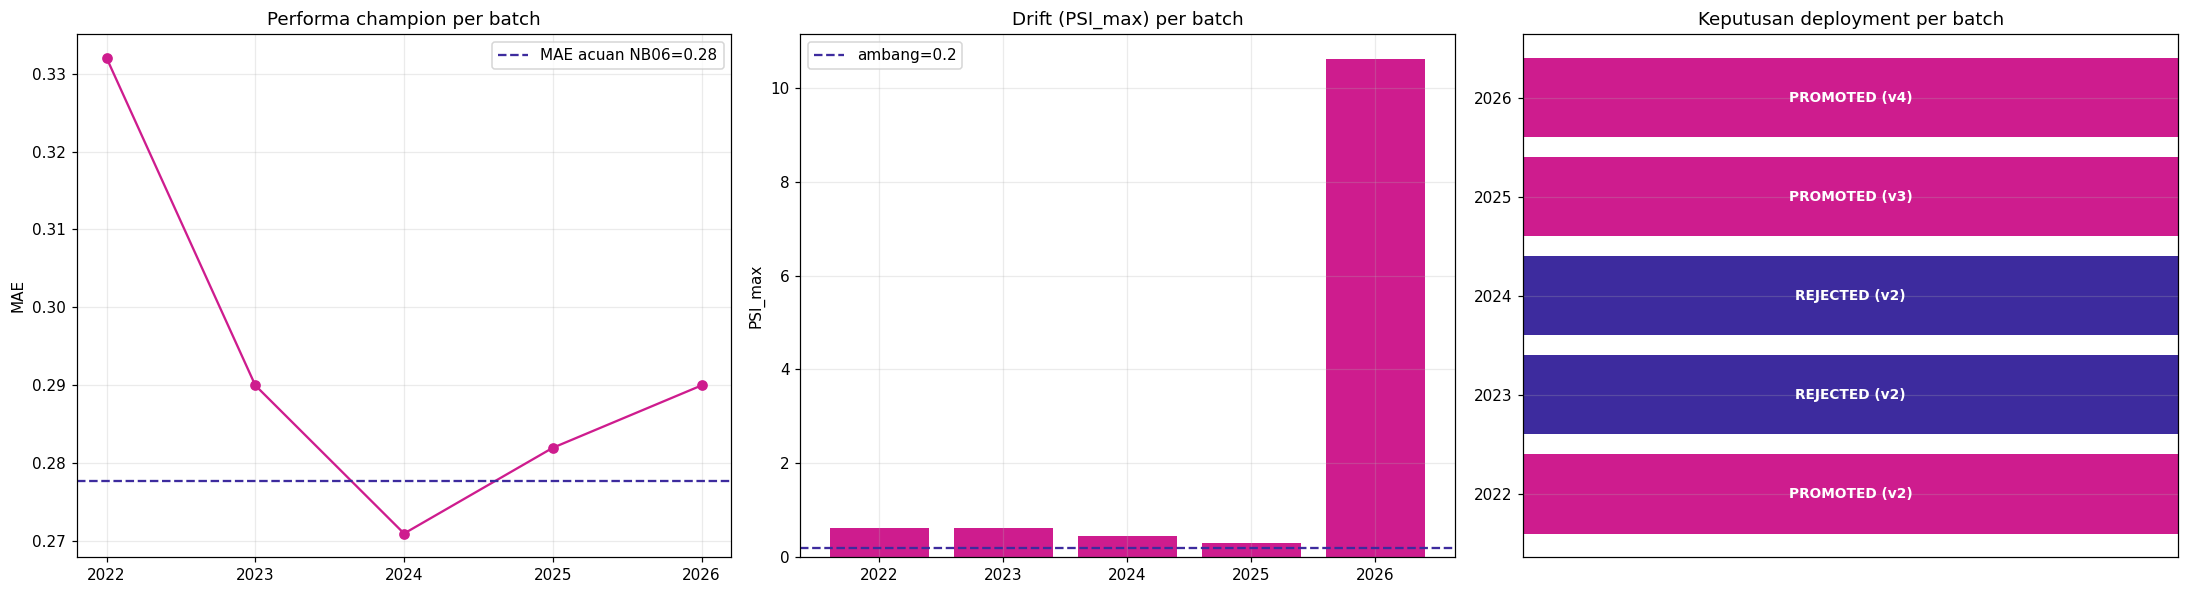

In [7]:
batch_rows=registry_df[registry_df['batch']!='init'].copy()
fig, axes=plt.subplots(1,3, figsize=(20,5.5))
dec_color={'KEEP':BRAND_LIGHT,'PROMOTED':BRAND_MAGENTA,'REJECTED':BRAND_INDIGO}

# (a) MAE champion per batch
axes[0].plot(batch_rows['batch'], batch_rows['MAE_batch'], '-o', color=BRAND_MAGENTA)
if not np.isnan(NB06_TEST_MAE):
    axes[0].axhline(NB06_TEST_MAE, ls='--', color=BRAND_INDIGO, label=f'MAE acuan NB06={NB06_TEST_MAE:.2f}')
axes[0].set_title('Performa champion per batch'); axes[0].set_ylabel('MAE'); axes[0].legend()

# (b) PSI_max per batch vs ambang
bars=axes[1].bar(batch_rows['batch'], batch_rows['psi_max'], color=[BRAND_MAGENTA if d else BRAND_LIGHT for d in batch_rows['drift_detected']])
axes[1].axhline(PSI_THRESHOLD, ls='--', color=BRAND_INDIGO, label=f'ambang={PSI_THRESHOLD}')
axes[1].set_title('Drift (PSI_max) per batch'); axes[1].set_ylabel('PSI_max'); axes[1].legend()

# (c) Keputusan per batch
y=np.arange(len(batch_rows))
axes[2].barh(y, [1]*len(batch_rows), color=[dec_color.get(d,BRAND_VIOLET) for d in batch_rows['decision']])
axes[2].set_yticks(y); axes[2].set_yticklabels(batch_rows['batch'])
for i,(d,v) in enumerate(zip(batch_rows['decision'], batch_rows['version'])):
    axes[2].text(0.5,i,f'{d} (v{v})', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
axes[2].set_xlim(0,1); axes[2].set_xticks([]); axes[2].set_title('Keputusan deployment per batch')
fig.tight_layout(); plt.show()